# Musica notebook

Ce notebook lance le pipeline de reconnaissance d'accords : dataset, Chroma-CQT, CNN, cache, évaluation et prédictions.

Le setup doit être fait avant d'exécuter les cellules. Si les caches existent, ils sont réutilisés.


In [60]:
import sys
from pathlib import Path
from musica.modeling import (
    ChordDataset,
    ChordEvaluator,
    ChordPredictor,
    ChordTrainer,
    FeatureExtractor,
    MusicaConfig,
    PreparedData,
)
from notebook_helpers import (
    dataset_audit,
    display_model_summary,
    display_prediction_summary,
    evaluate_predictions,
    plot_audio_and_feature,
    plot_confusion_matrix,
    plot_dataset_overview,
    plot_error_analysis,
    plot_example_predictions,
    plot_split_distribution,
    plot_test_metrics,
    plot_training_curves,
    setup_notebook_style,
    show_classification_report_dataframe,
    show_dataset_summary,
    show_table,
)

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

setup_notebook_style()

## 1. Configuration

`musica.toml` fixe les chemins, les paramètres audio, les splits et les options d'entraînement.

Le setup doit déjà avoir été lancé :

```bash
uv sync --extra dev
uv run musica setup-env
```

La cellule suivante vérifie les dossiers audio. Si un dossier manque, elle s'arrête avec les commandes à lancer.


2026-07-10 17:35:21.174 | INFO     | musica.config:load:232 - Chargement de la configuration: musica.toml
2026-07-10 17:35:21.175 | INFO     | musica.config:load:235 - Configuration chargee: epochs=60, batch_size=32, lr=0.001, force_retrain=False


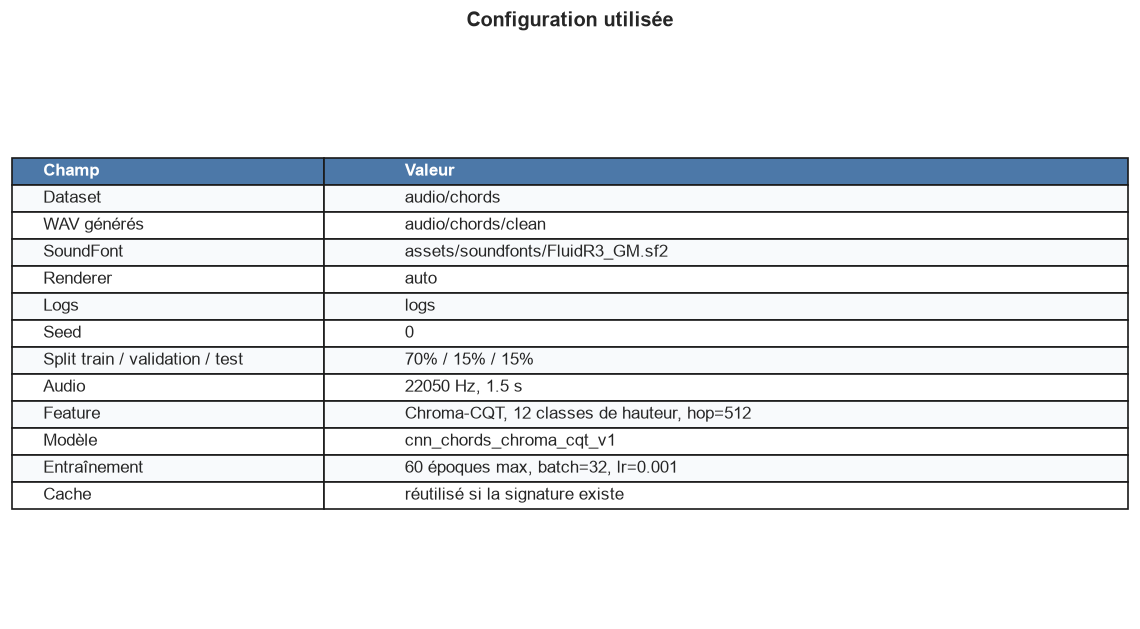

In [61]:
config = MusicaConfig.load()
if config.force_retrain:
    config = config.model_copy(
        update={"training": config.training.model_copy(update={"force_retrain": False})}
    )

dataset_dir = config.resolve_path(PROJECT_ROOT, config.dataset_dir)
clean_output_dir = config.resolve_path(PROJECT_ROOT, config.clean_output_dir)
soundfont_path = config.resolve_path(PROJECT_ROOT, config.soundfont_path)
logs_dir = config.resolve_path(PROJECT_ROOT, config.logs_dir)

show_table(
    "Configuration utilisée",
    [
        ("Dataset", dataset_dir.relative_to(PROJECT_ROOT)),
        ("WAV générés", clean_output_dir.relative_to(PROJECT_ROOT)),
        ("SoundFont", soundfont_path.relative_to(PROJECT_ROOT)),
        ("Renderer", config.renderer),
        ("Logs", logs_dir.relative_to(PROJECT_ROOT)),
        ("Seed", config.seed),
        ("Split train / validation / test",
         f"{1 - config.val_ratio - config.test_ratio:.0%} / {config.val_ratio:.0%} / {config.test_ratio:.0%}"),
        ("Audio", f"{config.sample_rate} Hz, {config.target_duration:.1f} s"),
        ("Feature", f"Chroma-CQT, {config.n_chroma} classes de hauteur, hop={config.hop_length}"),
        ("Modèle", config.model_architecture),
        ("Entraînement", f"{config.epochs} époques max, batch={config.batch_size}, lr={config.learning_rate}"),
        ("Cache", "réutilisé si la signature existe"),
    ],
)

## 2. Check env

Aucune génération ici. On vérifie seulement que `clean`, `noisy`, `realistic` et `recorded` sont prêts.


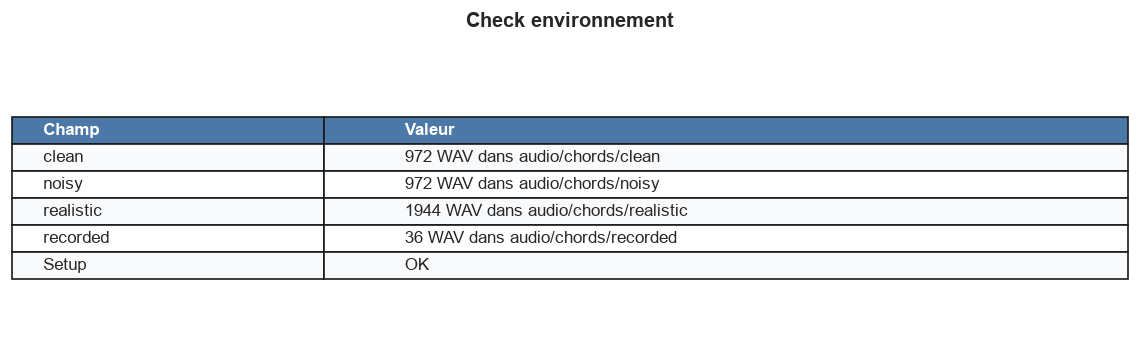

In [62]:
def wav_count(directory: Path) -> int:
    return len(list(directory.rglob("*.wav"))) if directory.exists() else 0


def relative(path: Path) -> Path:
    return path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path


noisy_output_dir = config.resolve_path(PROJECT_ROOT, config.noisy_output_dir)
realistic_output_dir = config.resolve_path(PROJECT_ROOT, config.realistic_output_dir)
recorded_dir = config.resolve_path(PROJECT_ROOT, config.recorded_audio_dir)
recorded_source_dir = PROJECT_ROOT / "assets" / "recorded"

audio_checks = {
    "clean": clean_output_dir,
    "noisy": noisy_output_dir,
    "realistic": realistic_output_dir,
    "recorded": recorded_dir,
}
audio_counts = {name: wav_count(directory) for name, directory in audio_checks.items()}
recorded_source_files = (
    {path.relative_to(recorded_source_dir) for path in recorded_source_dir.rglob("*.wav")}
    if recorded_source_dir.exists()
    else set()
)
recorded_target_files = (
    {path.relative_to(recorded_dir) for path in recorded_dir.rglob("*.wav")}
    if recorded_dir.exists()
    else set()
)
missing_recorded_files = sorted(recorded_source_files - recorded_target_files)

setup_issues = []
for name in ("clean", "noisy", "realistic"):
    if audio_counts[name] == 0:
        setup_issues.append(f"Aucun WAV trouvé dans `{relative(audio_checks[name])}`.")
if not recorded_dir.is_dir():
    setup_issues.append(f"Le dossier `{relative(recorded_dir)}` est absent.")
elif recorded_source_files and missing_recorded_files:
    setup_issues.append(
        f"{len(missing_recorded_files)} WAV de `assets/recorded` ne sont pas copiés "
        f"dans `{relative(recorded_dir)}`."
    )

if setup_issues:
    issues_markdown = "\n".join(f"- {issue}" for issue in setup_issues)
    print("Setup à lancer")
    print(issues_markdown)
    print("\nDepuis la racine du projet :")
    print("uv sync --extra dev")
    print("uv run musica setup-env")
    print("\nVoir README.md ou docs/SETUP.md.")
    raise RuntimeError("Setup incomplet: lancer `uv run musica setup-env`.")

show_table(
    "Check environnement",
    [
        ("clean", f"{audio_counts['clean']} WAV dans {relative(clean_output_dir)}"),
        ("noisy", f"{audio_counts['noisy']} WAV dans {relative(noisy_output_dir)}"),
        ("realistic", f"{audio_counts['realistic']} WAV dans {relative(realistic_output_dir)}"),
        ("recorded", f"{audio_counts['recorded']} WAV dans {relative(recorded_dir)}"),
        ("Setup", "OK"),
    ],
)

## 3. Dataset

On charge les WAV, les splits et les features Chroma-CQT. Les graphiques servent surtout à repérer un dataset vide, déséquilibré ou mal réparti.


2026-07-10 17:35:21.314 | INFO     | musica.modeling.dataset:discover:34 - Recherche des fichiers WAV dans /Users/raharison/docs/projects/musica/audio/chords
2026-07-10 17:35:21.333 | INFO     | musica.modeling.dataset:discover:45 - Dataset decouvert: 3924 fichiers audio, 36 classes
2026-07-10 17:35:21.333 | INFO     | musica.modeling.dataset:split:56 - Creation du split stratifie: val_ratio=0.15, test_ratio=0.15, seed=0
2026-07-10 17:35:21.387 | INFO     | musica.modeling.dataset:split:86 - Split pret: train=2772, validation=576, test=576
2026-07-10 17:35:21.636 | INFO     | musica.modeling.training:signature:152 - Signature du run: 513eb63271bd


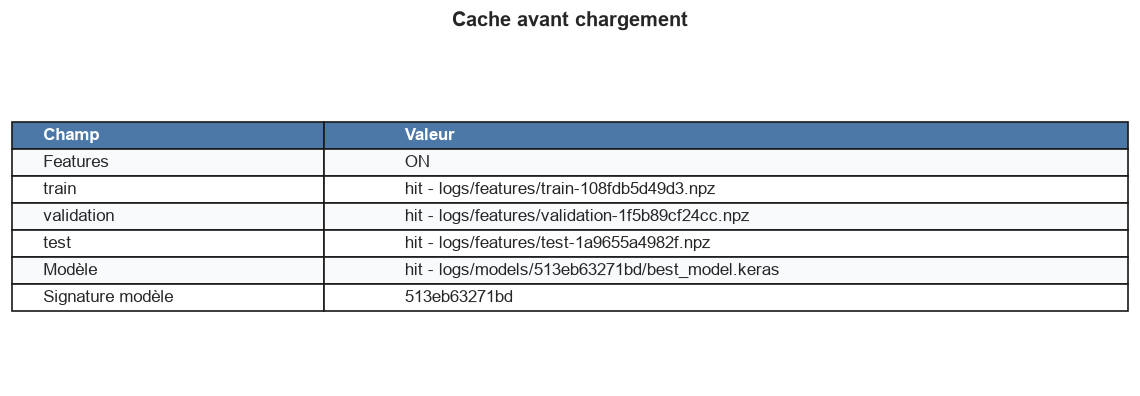

2026-07-10 17:35:21.754 | INFO     | musica.modeling.features:load_cached_features:127 - Cache hit features: /Users/raharison/docs/projects/musica/logs/features/train-108fdb5d49d3.npz shape=(2772, 65, 12, 1)
2026-07-10 17:35:21.772 | INFO     | musica.modeling.features:load_cached_features:127 - Cache hit features: /Users/raharison/docs/projects/musica/logs/features/validation-1f5b89cf24cc.npz shape=(576, 65, 12, 1)
2026-07-10 17:35:21.788 | INFO     | musica.modeling.features:load_cached_features:127 - Cache hit features: /Users/raharison/docs/projects/musica/logs/features/test-1a9655a4982f.npz shape=(576, 65, 12, 1)


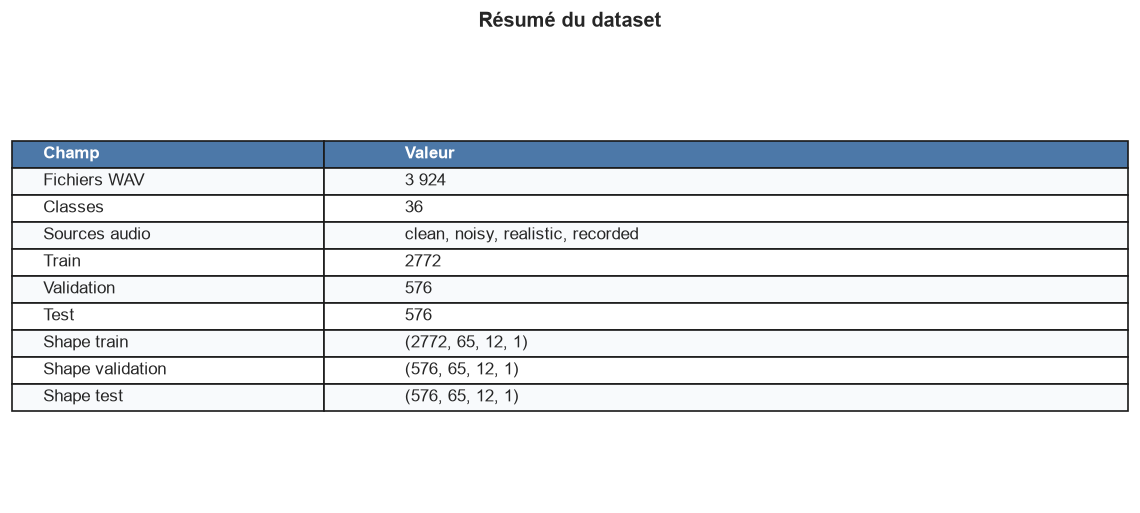

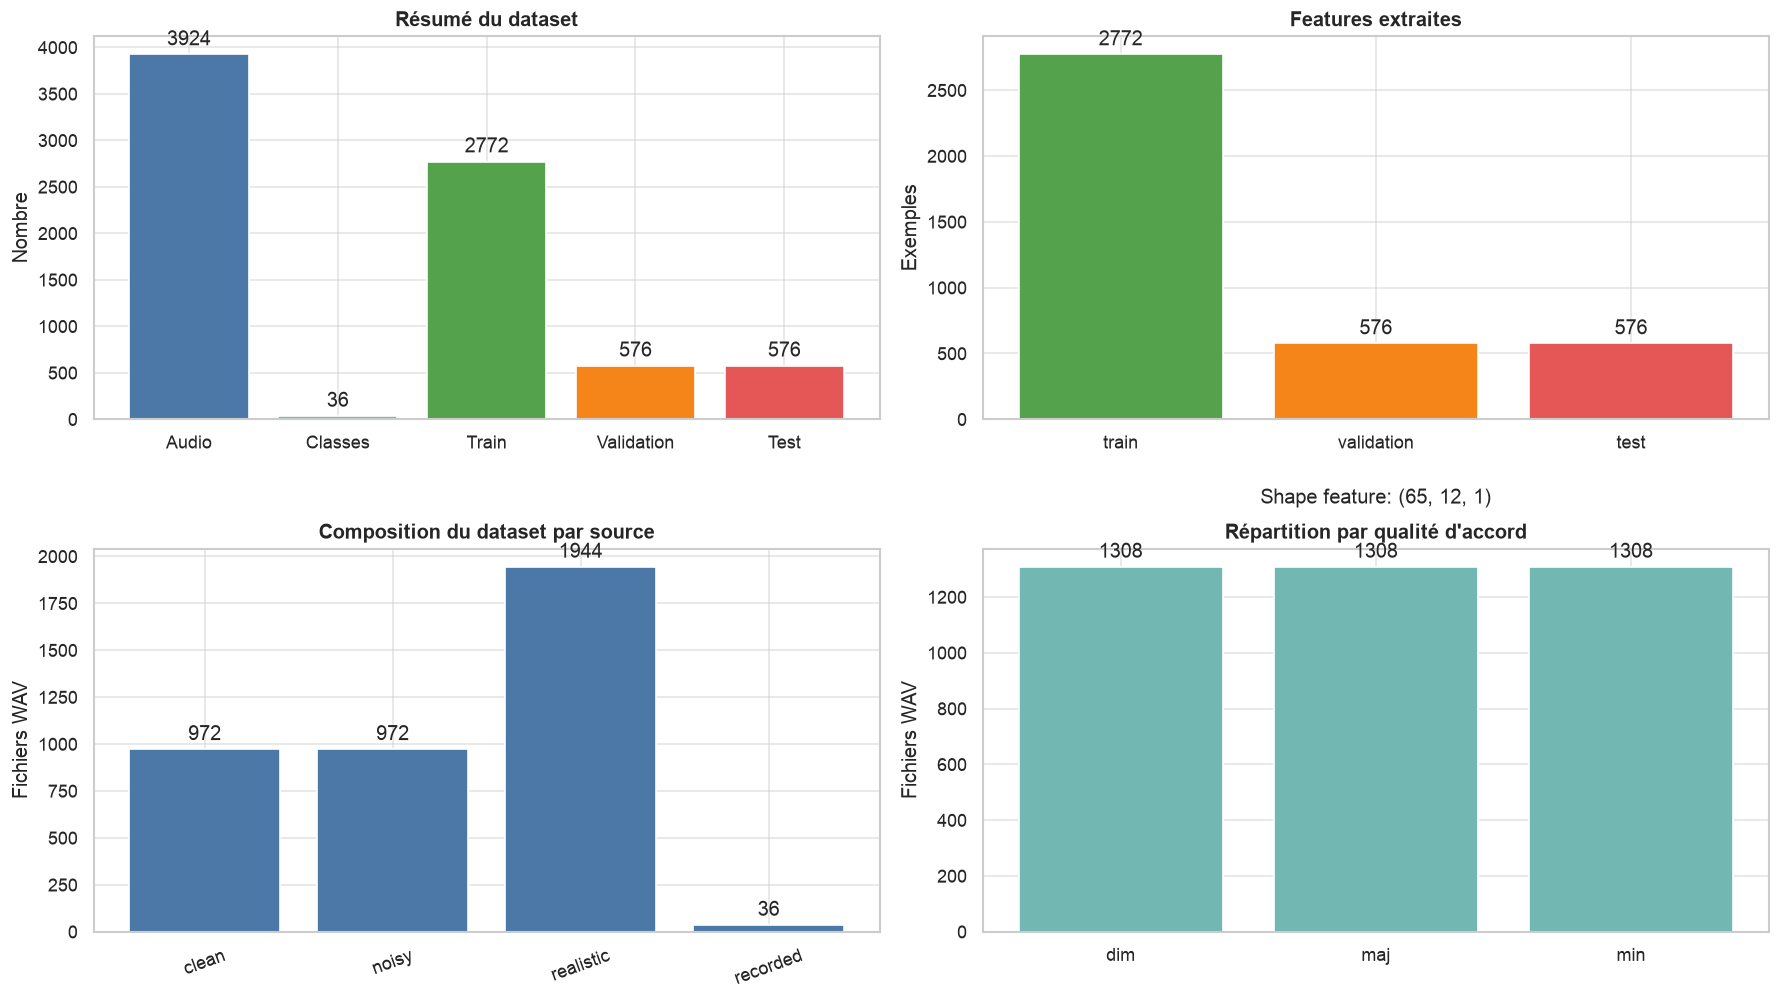

In [63]:
dataset = ChordDataset(config, project_root=PROJECT_ROOT).discover()
split = dataset.split()
extractor = FeatureExtractor(config, dataset, project_root=PROJECT_ROOT)
trainer_for_cache = ChordTrainer(config, dataset, project_root=PROJECT_ROOT)

feature_cache_paths = {
    "train": extractor.feature_cache_path(split.train_paths, split_name="train"),
    "validation": extractor.feature_cache_path(split.val_paths, split_name="validation"),
    "test": extractor.feature_cache_path(split.test_paths, split_name="test"),
}
model_signature = trainer_for_cache.signature(split)
model_cache_path, model_history_log_path = trainer_for_cache.cached_model_paths(model_signature)


def cache_status(path: Path) -> str:
    return f"{'hit' if path.exists() else 'miss'} - {relative(path)}"


show_table(
    "Cache avant chargement",
    [
        ("Features", "ON" if config.cache_features else "OFF"),
        ("train", cache_status(feature_cache_paths["train"])),
        ("validation", cache_status(feature_cache_paths["validation"])),
        ("test", cache_status(feature_cache_paths["test"])),
        ("Modèle", cache_status(model_cache_path)),
        ("Signature modèle", model_signature),
    ],
)

x_train, y_train = extractor.load_features(split.train_paths, split_name="train")
x_val, y_val = extractor.load_features(split.val_paths, split_name="validation")
x_test, y_test = extractor.load_features(split.test_paths, split_name="test")
prepared = PreparedData(dataset, split, x_train, y_train, x_val, y_val, x_test, y_test)
audit = dataset_audit(prepared)
dataset = audit["dataset"]
split_paths = audit["split_paths"]
split_sizes = audit["split_sizes"]

show_dataset_summary(prepared, audit)
plot_dataset_overview(prepared, audit)

## 4. Splits

On vérifie que chaque accord reste représenté dans train, validation et test.


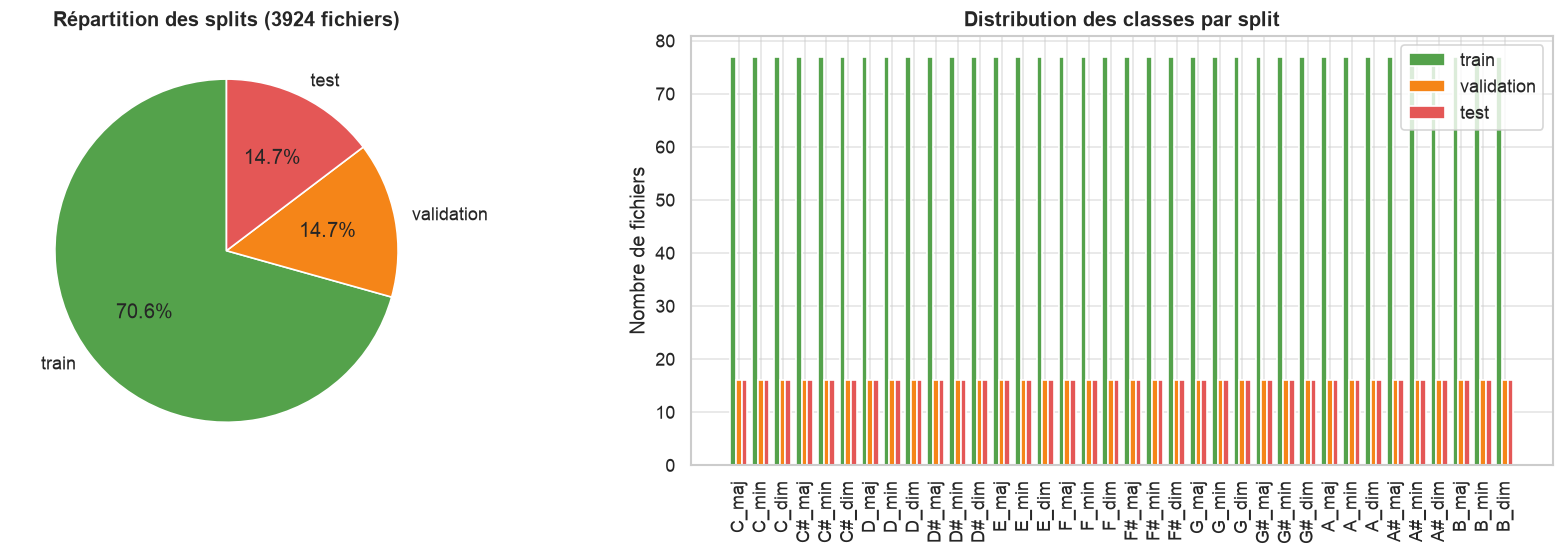

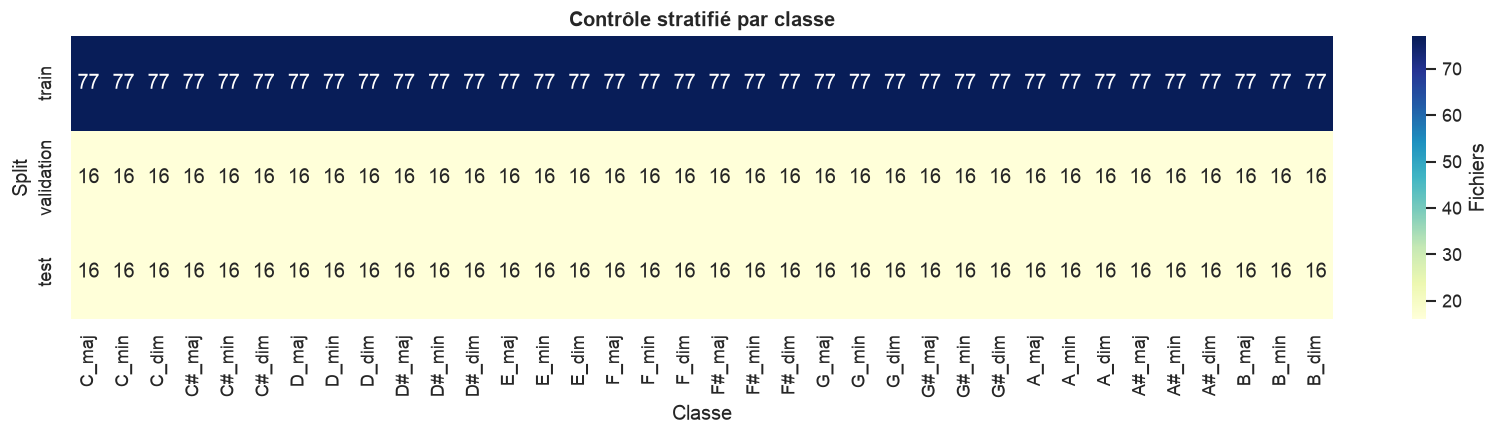

In [64]:
plot_split_distribution(dataset, audit)

## 5. Audio vers Chroma-CQT

Entrée du CNN : un Chroma-CQT, pas l'onde brute.


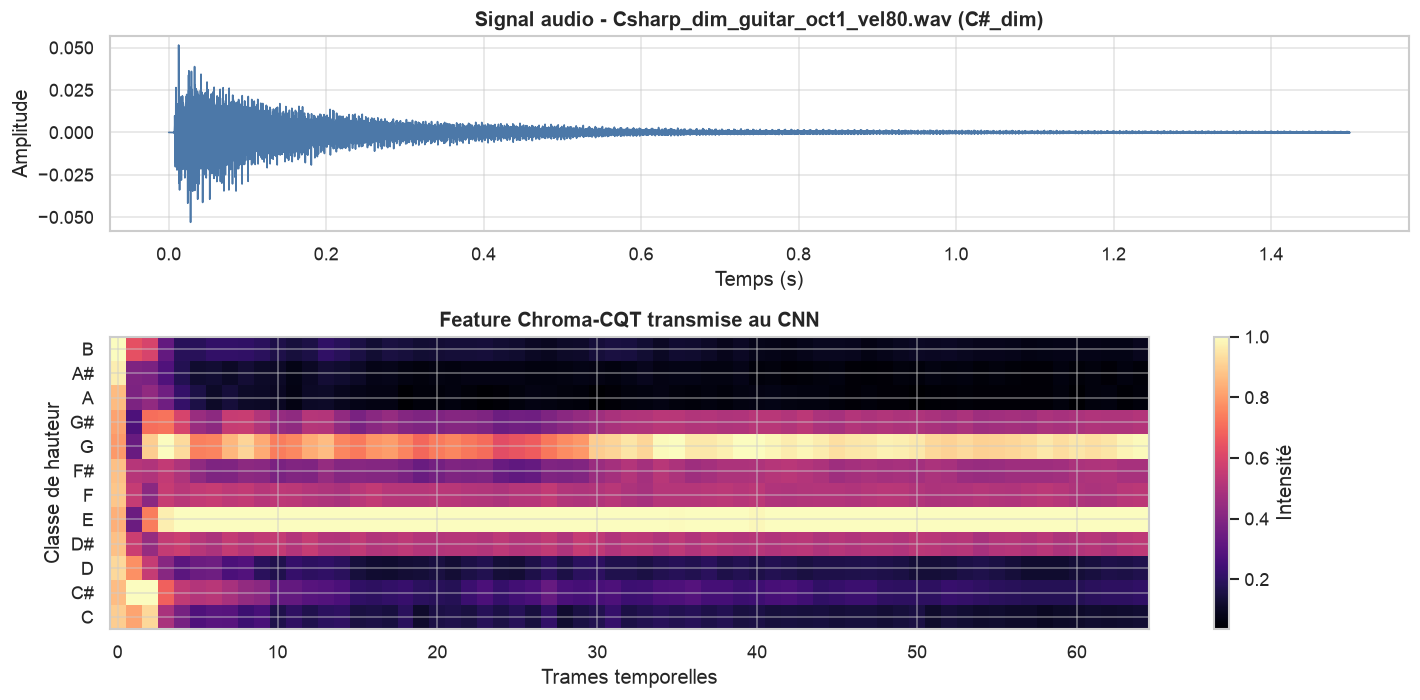

In [65]:
example_index = 0
example_path = prepared.split.train_paths[example_index]
example_label = dataset.label_from_path(example_path)
example_feature = prepared.x_train[example_index, :, :, 0]

plot_audio_and_feature(example_path, example_feature, example_label, config)

## 6. Modèle

Si la signature existe, on charge le modèle en cache. Sinon, entraînement.


2026-07-10 17:35:22.712 | INFO     | musica.modeling.training:signature:152 - Signature du run: 513eb63271bd
2026-07-10 17:35:22.712 | INFO     | musica.modeling.training:load_cached_model:159 - Verification du cache modele: /Users/raharison/docs/projects/musica/logs/models/513eb63271bd/best_model.keras
2026-07-10 17:35:22.713 | INFO     | musica.modeling.training:load_cached_model:161 - Cache hit: chargement de /Users/raharison/docs/projects/musica/logs/models/513eb63271bd/best_model.keras


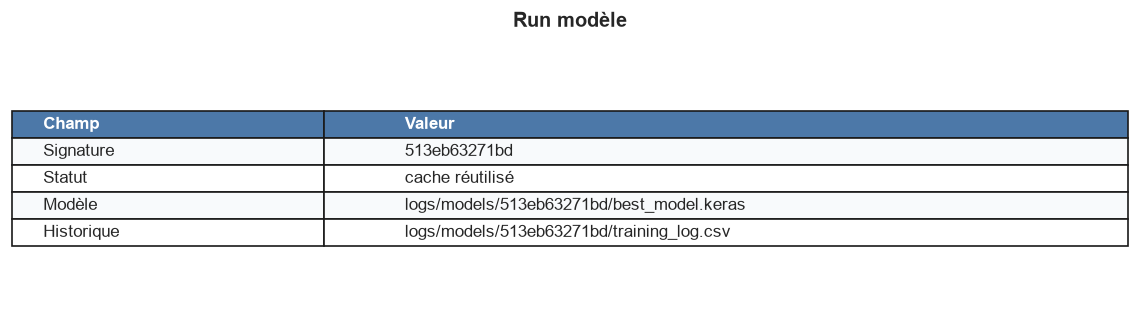

In [66]:
trainer = ChordTrainer(config, dataset, project_root=PROJECT_ROOT)
training = trainer.train_or_load(prepared)

show_table(
    "Run modèle",
    [
        ("Signature", training.signature),
        ("Statut", "cache réutilisé" if training.cache_hit else "modèle entraîné"),
        ("Modèle", training.model_path.relative_to(PROJECT_ROOT)),
        ("Historique", training.history_log_path.relative_to(PROJECT_ROOT)),
    ],
)

## 7. Architecture

Résumé du modèle chargé : normalisation, convolutions, pooling, dropout et sortie softmax.


In [67]:
display_model_summary(training.model)

Model: "cnn_chords"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 65, 12, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 65, 12, 32)     │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 65, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 65, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 12, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 12, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,001 (820.32 KB)

 Trainable params: 69,892 (273.02 KB)

 Non-trainable params: 323 (1.27 KB)

 Optimizer params: 139,786 (546.04 KB)

## 8. Courbes

On compare train et validation. Un écart qui s'ouvre trop indique du surapprentissage.


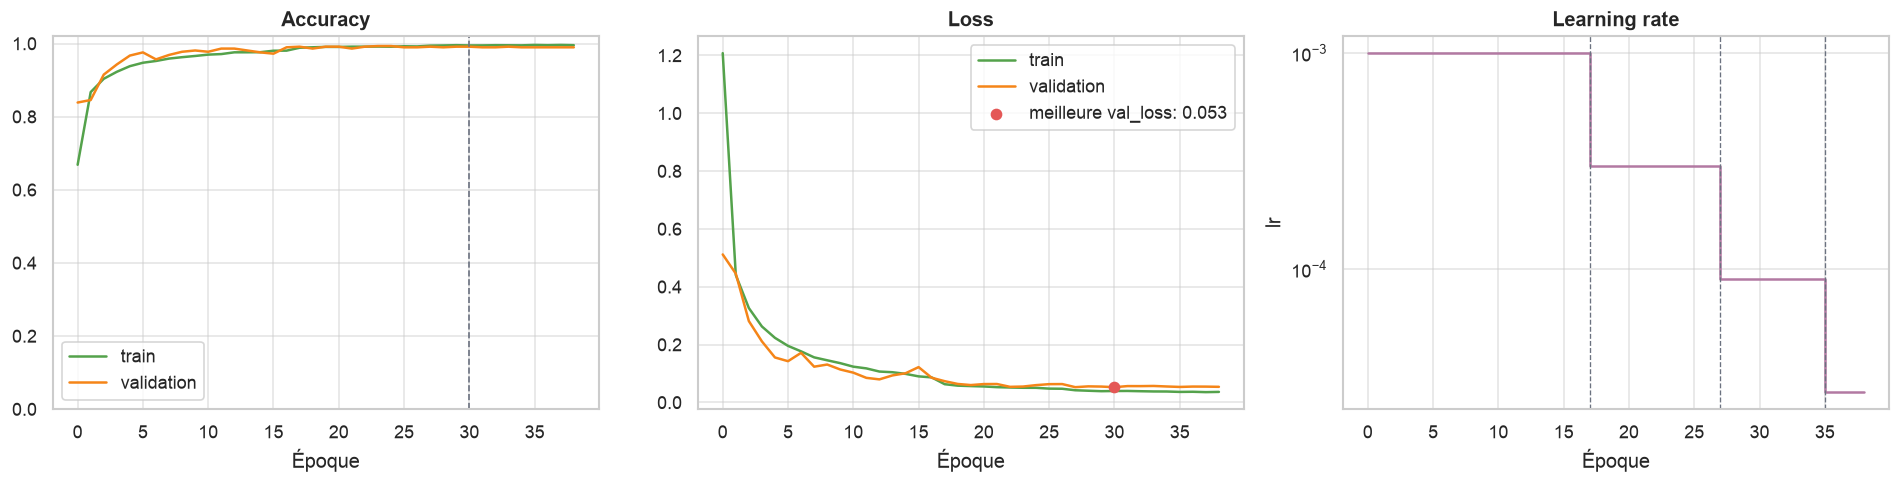

{'curves': {'epoch': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
         13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
         26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.]),
  'accuracy': array([0.66832012, 0.8671236 , 0.90349931, 0.92261904, 0.93801105,
         0.94739056, 0.95223063, 0.95878428, 0.9626022 , 0.96590906,
         0.96960676, 0.97107983, 0.97588986, 0.97598004, 0.97628069,
         0.98027897, 0.98048943, 0.98839587, 0.98968858, 0.99074072,
         0.99065053, 0.99140209, 0.99140209, 0.99161255, 0.99122173,
         0.99245429, 0.99203342, 0.99419791, 0.99467891, 0.99543047,
         0.99470901, 0.99482924, 0.99537039, 0.99519002, 0.99497956,
         0.9960618 , 0.99543047, 0.99609184, 0.99543047]),
  'learning_rate': array([1.00000005e-03, 1.00000005e-03, 1.00000005e-03, 1.00000005e-03,
         1.00000005e-03, 1.00000005e-03, 1.00000005e-03, 1.00000005e-03,
         1.00000005e-03, 1.00000005e-03,

In [68]:
plot_training_curves(training.history_log_path)

## 9. Test

Le test utilise les fichiers mis de côté. Matrice normalisée : confusions en pourcentage.


2026-07-10 17:35:22.996 | INFO     | musica.modeling.evaluation:evaluate:30 - Evaluation sur le test: 576 exemples
2026-07-10 17:35:23.414 | INFO     | musica.modeling.evaluation:evaluate:40 - Evaluation terminee: accuracy=0.9913, loss=0.0375, f1_macro=0.9913


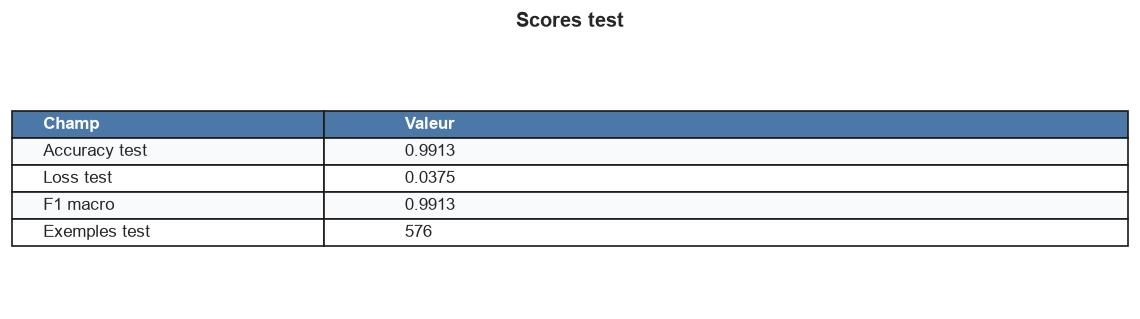

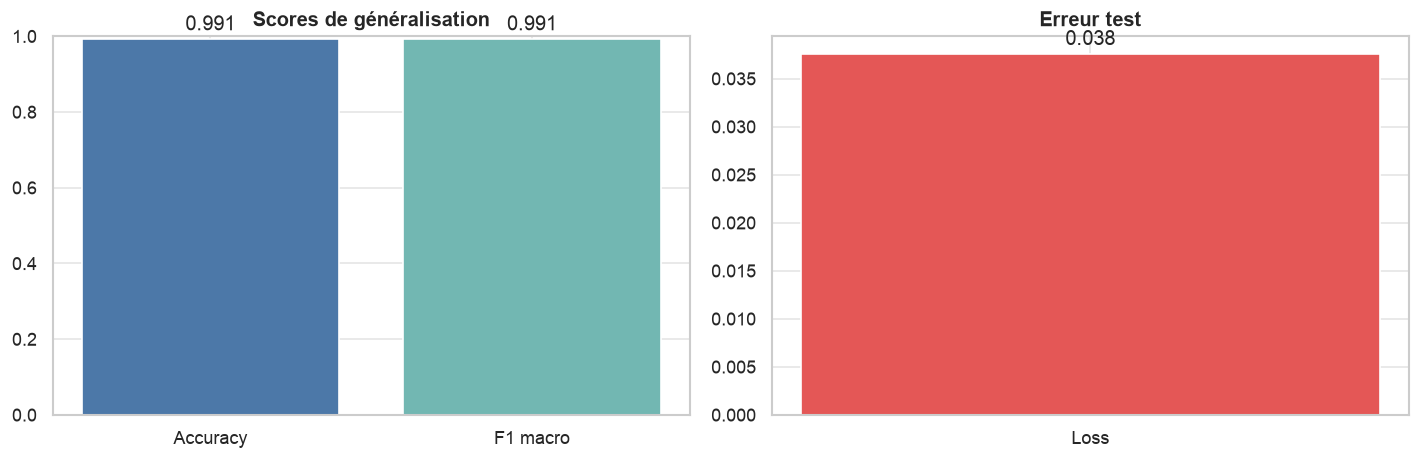

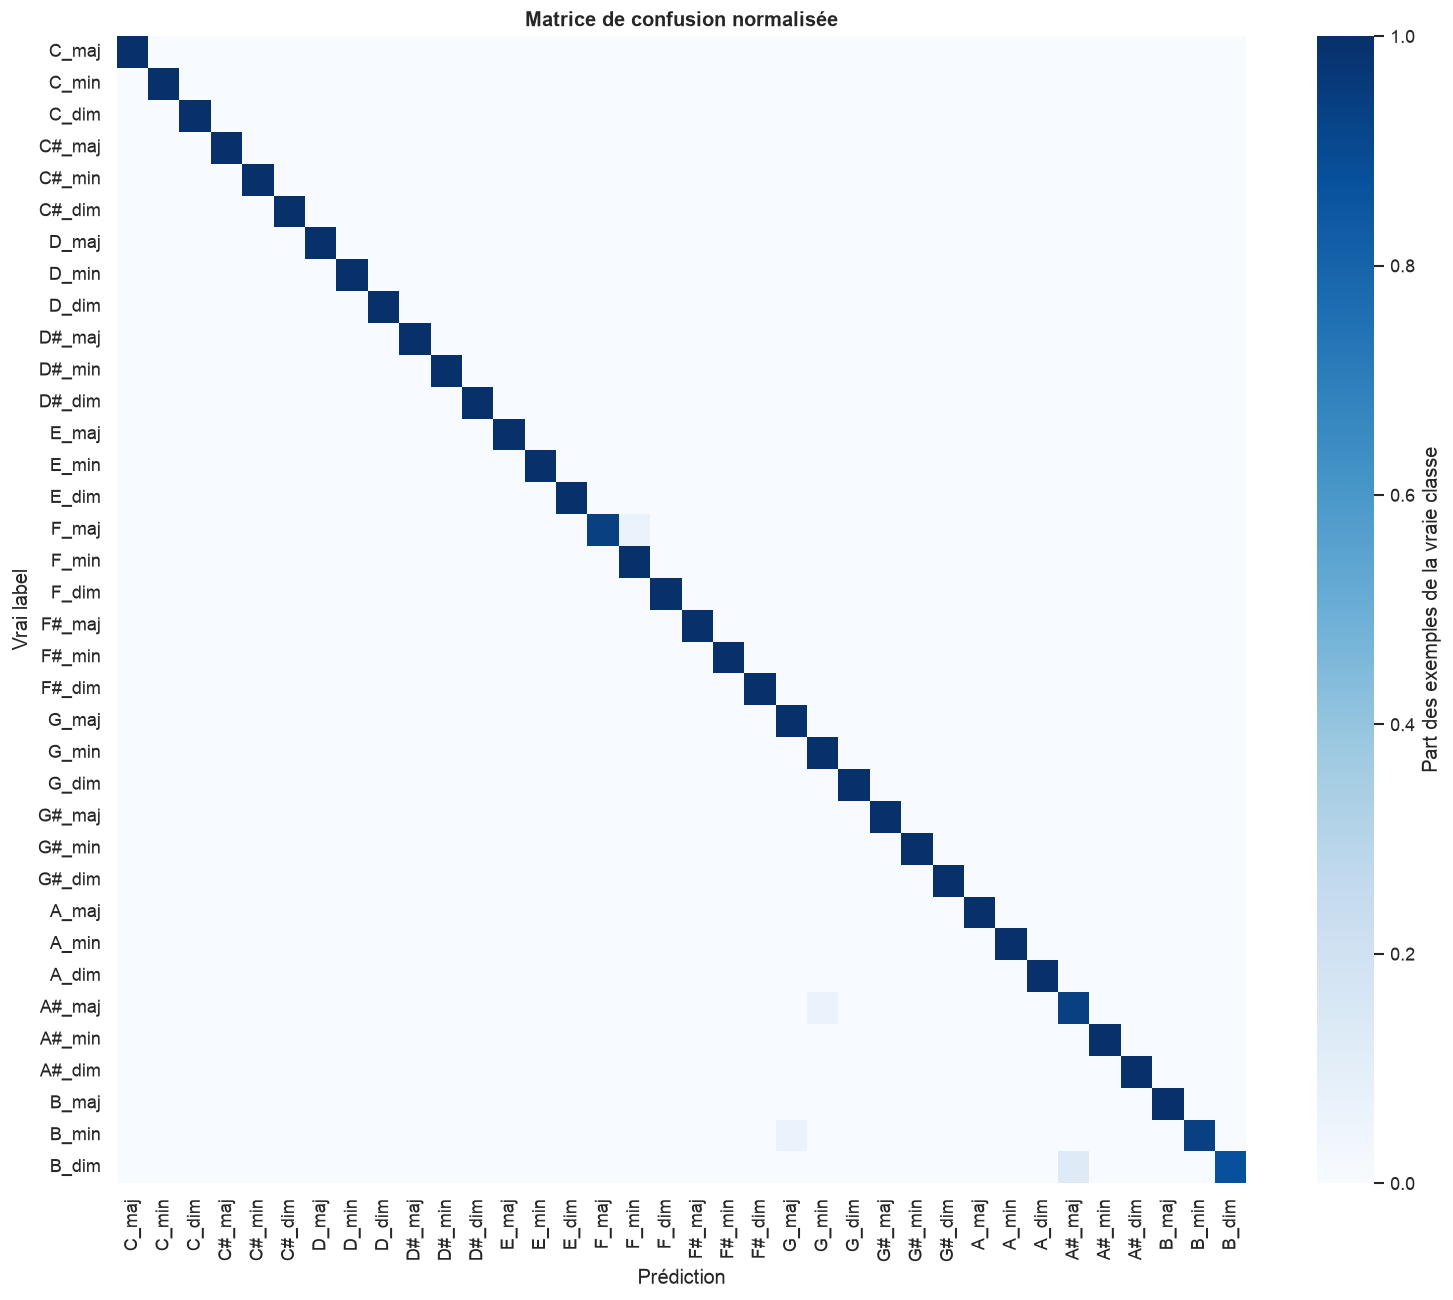

In [69]:
evaluator = ChordEvaluator()
evaluation = evaluator.evaluate(training.model, prepared.x_test, prepared.y_test, dataset.labels)
prediction_analysis = evaluate_predictions(training.model, prepared, dataset.labels)

show_table(
    "Scores test",
    [
        ("Accuracy test", f"{evaluation.test_accuracy:.4f}"),
        ("Loss test", f"{evaluation.test_loss:.4f}"),
        ("F1 macro", f"{evaluation.f1_macro:.4f}"),
        ("Exemples test", len(prepared.y_test)),
    ],
)
plot_test_metrics(evaluation)
plot_confusion_matrix(dataset.labels, prediction_analysis["cm_normalized"])

## 10. Rapport par classe

Précision, rappel, F1 et support pour chaque accord.


In [70]:
show_classification_report_dataframe(prediction_analysis["report"])

,precision,recall,f1-score,support
C_maj,1.000,1.000,1.000,16
C_min,1.000,1.000,1.000,16
C_dim,1.000,1.000,1.000,16
C#_maj,1.000,1.000,1.000,16
C#_min,1.000,1.000,1.000,16
C#_dim,1.000,1.000,1.000,16
D_maj,1.000,1.000,1.000,16
D_min,1.000,1.000,1.000,16
D_dim,1.000,1.000,1.000,16
D#_maj,1.000,1.000,1.000,16


,precision,recall,f1-score,support
C_maj,1.000,1.000,1.000,16
C_min,1.000,1.000,1.000,16
C_dim,1.000,1.000,1.000,16
C#_maj,1.000,1.000,1.000,16
C#_min,1.000,1.000,1.000,16
C#_dim,1.000,1.000,1.000,16
D_maj,1.000,1.000,1.000,16
D_min,1.000,1.000,1.000,16
D_dim,1.000,1.000,1.000,16
D#_maj,1.000,1.000,1.000,16


## 11. Analyse des erreurs

Les scores globaux ne suffisent pas. Ici, on regarde les classes faibles et les confusions hors diagonale.


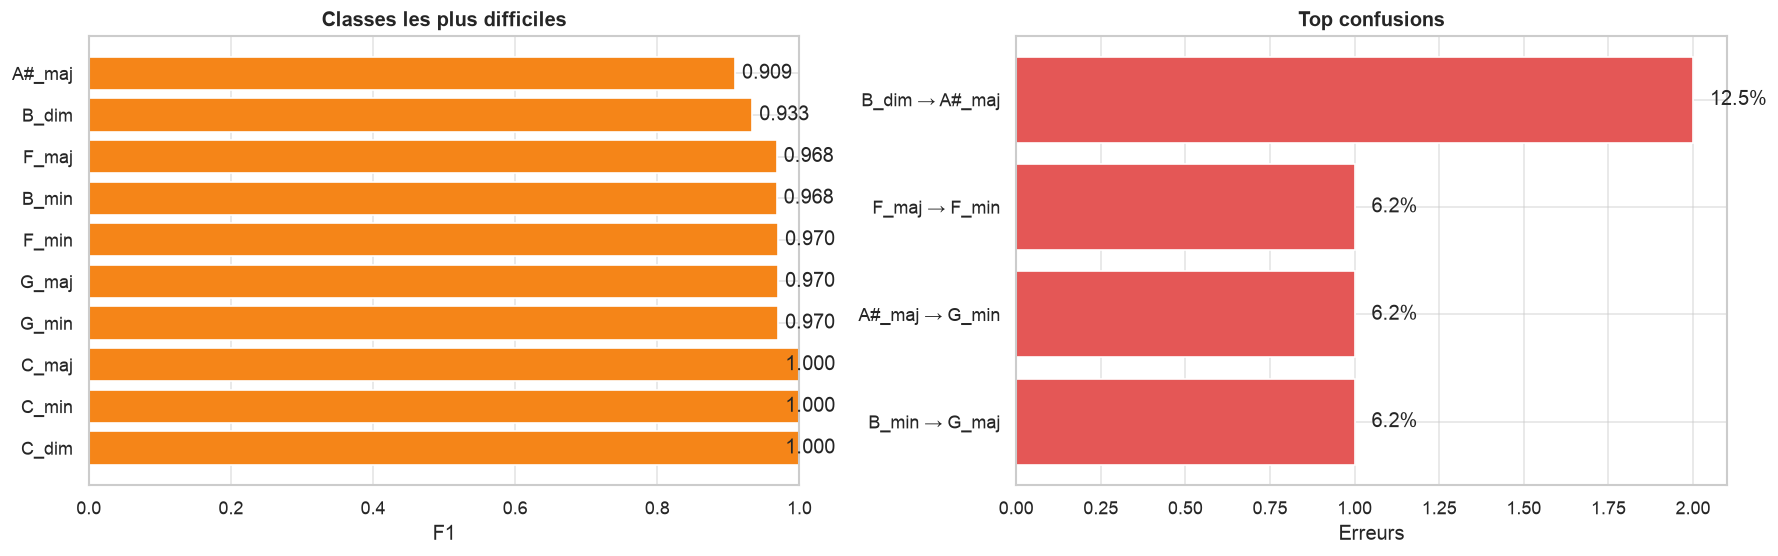

[{'true': 'B_dim', 'pred': 'A#_maj', 'count': 2, 'rate': 0.125},
 {'true': 'F_maj', 'pred': 'F_min', 'count': 1, 'rate': 0.0625},
 {'true': 'A#_maj', 'pred': 'G_min', 'count': 1, 'rate': 0.0625},
 {'true': 'B_min', 'pred': 'G_maj', 'count': 1, 'rate': 0.0625}]

In [71]:
plot_error_analysis(
    dataset.labels,
    prediction_analysis["report"],
    prediction_analysis["cm"],
    prediction_analysis["cm_normalized"],
)

## 12. Exemples WAV

Prédictions top-k sur les fichiers du dossier `examples/`.


2026-07-10 17:35:23.955 | INFO     | musica.modeling.prediction:predict:29 - Prediction de l'audio: /Users/raharison/docs/projects/musica/examples/E_dim.wav
2026-07-10 17:35:24.034 | INFO     | musica.modeling.prediction:predict:29 - Prediction de l'audio: /Users/raharison/docs/projects/musica/examples/E_maj.wav
2026-07-10 17:35:24.067 | INFO     | musica.modeling.prediction:predict:29 - Prediction de l'audio: /Users/raharison/docs/projects/musica/examples/G_maj.wav
2026-07-10 17:35:24.100 | INFO     | musica.modeling.prediction:predict:29 - Prediction de l'audio: /Users/raharison/docs/projects/musica/examples/G_min.wav


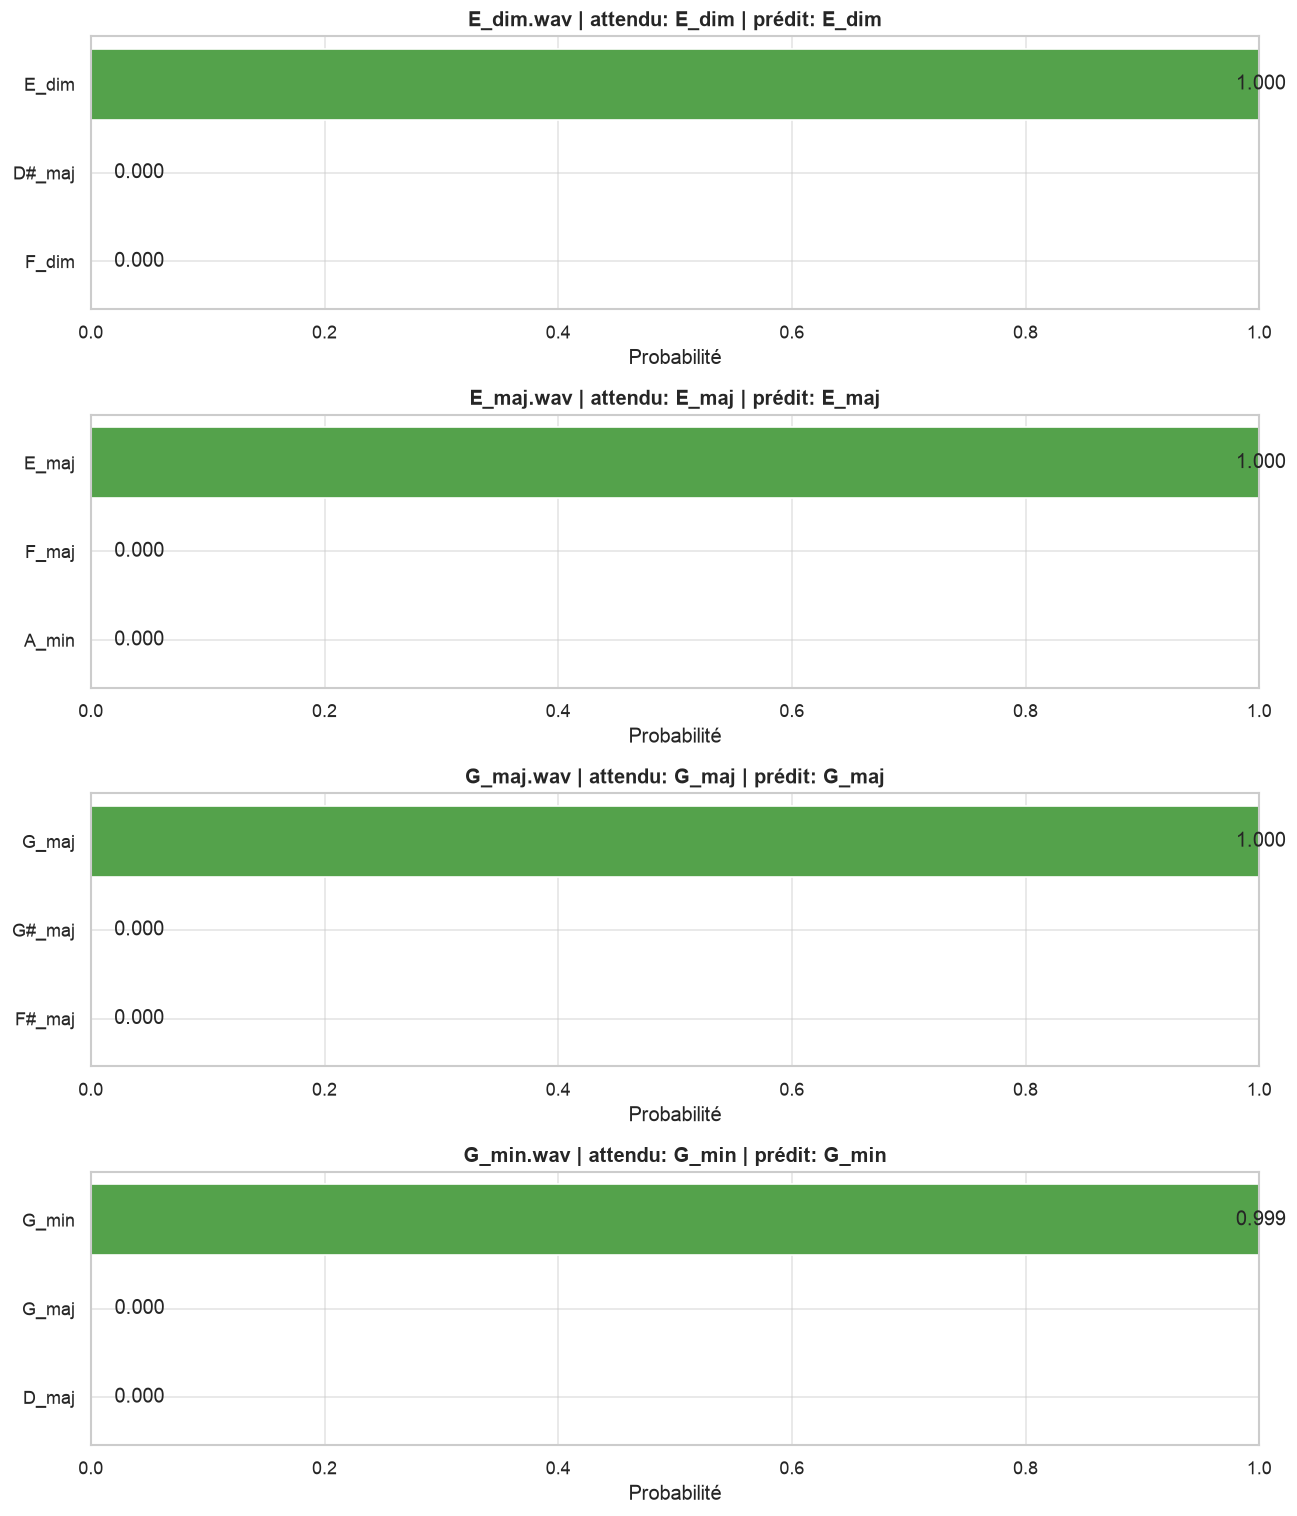

Résumé des prédictions :
- `E_dim.wav` : attendu `E_dim`, prédit `E_dim` avec 100.0%
- `E_maj.wav` : attendu `E_maj`, prédit `E_maj` avec 100.0%
- `G_maj.wav` : attendu `G_maj`, prédit `G_maj` avec 100.0%
- `G_min.wav` : attendu `G_min`, prédit `G_min` avec 99.9%

In [72]:
predictor = ChordPredictor(config, FeatureExtractor(config, dataset, project_root=PROJECT_ROOT), dataset.labels)
example_audio_files = config.examples.audio_paths(PROJECT_ROOT)

prediction_summaries = plot_example_predictions(
    predictor,
    training.model,
    dataset,
    example_audio_files,
)
display_prediction_summary(prediction_summaries)

## 13. Limites

- Bons scores sur le split test, mais beaucoup de données restent générées ou augmentées.
- Il faut plus de vrais enregistrements pour savoir si le modèle tient hors dataset.
- Le Chroma-CQT convient aux accords isolés ; il ne traite pas encore un morceau complet avec changements d'accords.
- Suite logique : plus de `recorded`, métriques par source, tests sur datasets externes annotés.
